In [1]:

# 1. IMPORTS & CONFIG

import sys, os, glob, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc as sk_auc
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

CSV_FOLDER     = './MachineLearningCVE'
LABEL_COL      = 'Label'
N_FOLDS        = 10
TEST_SIZE      = 0.3
RANDOM_STATE   = 42
OUTPUT_DIR     = '.'

os.makedirs(OUTPUT_DIR, exist_ok=True)

import sklearn
print(f'Scikit-learn : {sklearn.__version__}')
print(f'LightGBM     : {lgb.__version__}')
print(f'Pandas       : {pd.__version__}')

Scikit-learn : 1.8.0
LightGBM     : 4.6.0
Pandas       : 3.0.2


In [2]:
# LOAD THE DATA

print('Loading data...')
csv_files = sorted(glob.glob(os.path.join(CSV_FOLDER, '*.csv')))
if not csv_files:
    raise FileNotFoundError(f'No CSV files found in {CSV_FOLDER}')

dfs = []
for f in csv_files:
    print(f'  -> {os.path.basename(f)}')
    tmp = pd.read_csv(f, low_memory=False)
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
print(f'Total rows loaded: {len(df):,}')


# PREPROCESSING

df.columns = df.columns.str.strip()

drop_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp',
             'Src IP', 'Dst IP', 'src_ip', 'dst_ip']
drop_cols = [c for c in drop_cols if c in df.columns]
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
thresh = len(df) * 0.5
df.dropna(axis=1, thresh=thresh, inplace=True)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df):,}')
print(f'Shape after cleanup: {df.shape}')

Loading data...
  -> Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  -> Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  -> Friday-WorkingHours-Morning.pcap_ISCX.csv
  -> Monday-WorkingHours.pcap_ISCX.csv
  -> Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  -> Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  -> Tuesday-WorkingHours.pcap_ISCX.csv
  -> Wednesday-workingHours.pcap_ISCX.csv
Total rows loaded: 2,830,743
Duplicates removed: 308,381
Shape after cleanup: (2522362, 79)


Plotting dataset distribution...


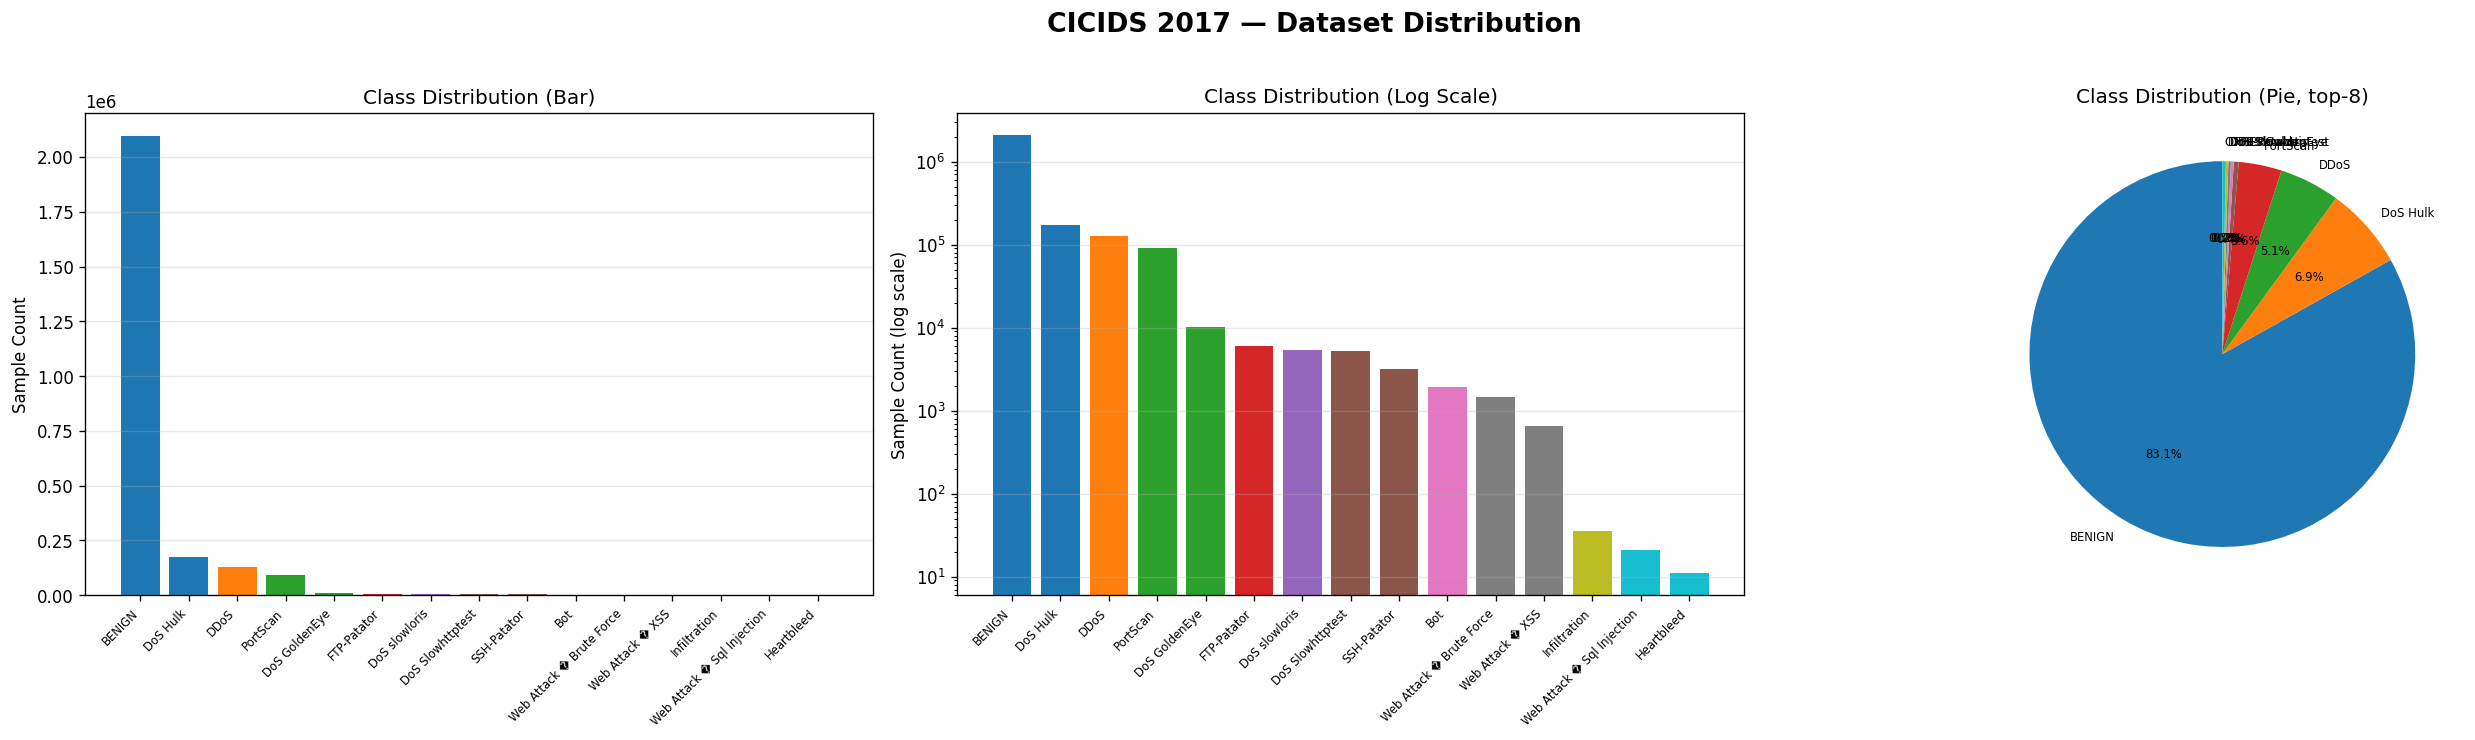

Saved: dataset_distribution.png


In [3]:

# DATASET DISTRIBUTION PLOTTING

print('Plotting dataset distribution...')

class_counts = df[LABEL_COL].value_counts()
class_names_raw = class_counts.index.tolist()
n_classes_raw   = len(class_names_raw)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('CICIDS 2017 — Dataset Distribution', fontsize=16, fontweight='bold', y=1.02)

colors_bar = plt.cm.tab10(np.linspace(0, 1, n_classes_raw))
axes[0].bar(range(n_classes_raw), class_counts.values, color=colors_bar)
axes[0].set_xticks(range(n_classes_raw))
axes[0].set_xticklabels(class_names_raw, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Sample Count')
axes[0].set_title('Class Distribution (Bar)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(n_classes_raw), class_counts.values, color=colors_bar)
axes[1].set_xticks(range(n_classes_raw))
axes[1].set_xticklabels(class_names_raw, rotation=45, ha='right', fontsize=7)
axes[1].set_yscale('log')
axes[1].set_ylabel('Sample Count (log scale)')
axes[1].set_title('Class Distribution (Log Scale)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

top_n = 8
if n_classes_raw > top_n:
    top_counts = class_counts.head(top_n)
    other_sum = class_counts.iloc[top_n:].sum()
    pie_data = pd.concat([top_counts, pd.Series({'OTHER': other_sum})])
else:
    pie_data = class_counts
colors_pie = plt.cm.tab10(np.linspace(0, 1, len(pie_data)))
axes[2].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90, textprops={'fontsize': 7})
axes[2].set_title(f'Class Distribution (Pie, top-{top_n})', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dataset_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dataset_distribution.png')

In [4]:

# LABEL ENCODING & SPLIT

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df[LABEL_COL].astype(str))
class_names = le.classes_
n_classes   = len(class_names)

print(f'Number of classes: {n_classes}')
for i, name in enumerate(class_names):
    print(f'  {i:2d}: {name}')

X = df.drop(columns=[LABEL_COL, 'label_enc'])
X = X.select_dtypes(include=[np.number])
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape},  Test: {X_test.shape}')

scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
print('Normalization: Min-Max [0, 1]')

del df
gc.collect()

Number of classes: 15
   0: BENIGN
   1: Bot
   2: DDoS
   3: DoS GoldenEye
   4: DoS Hulk
   5: DoS Slowhttptest
   6: DoS slowloris
   7: FTP-Patator
   8: Heartbleed
   9: Infiltration
  10: PortScan
  11: SSH-Patator
  12: Web Attack � Brute Force
  13: Web Attack � Sql Injection
  14: Web Attack � XSS
Train: (1765653, 78),  Test: (756709, 78)
Normalization: Min-Max [0, 1]


4792

In [ ]:

# BASE LEARNERS

print('Defining base learners...')

# For LightGBM, we will use a more aggressive set of hyperparameters to encourage diversity and better generalization.
lgbm_model = lgb.LGBMClassifier(
    objective         = 'multiclass',
    metric            = 'multi_logloss',
    num_class         = n_classes,
    n_estimators      = 100,
    learning_rate     = 0.05,
    max_depth         = 8,
    num_leaves        = 63,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    class_weight      = 'balanced',
    device            = 'cpu',
    random_state      = RANDOM_STATE,
    n_jobs            = 2,
    verbose           = -1,
)
print('  LightGBM OK')

# For Bagging + Decision Tree, we will use Random Subspace method (bootstrap_features=True)
base_dt = DecisionTreeClassifier(
    criterion='gini', max_depth=10,
    min_samples_split=20, min_samples_leaf=10, random_state=RANDOM_STATE,
)

# Using Random Subspace method to increase diversity among the base learners in the ensemble.
bagging_model = BaggingClassifier(
    estimator=base_dt, n_estimators=100, max_samples=0.8, max_features=0.5,
    bootstrap=True, bootstrap_features=False, n_jobs=2,
    random_state=RANDOM_STATE, verbose=0,
)
print('  Bagging + DT (Random Subspace) OK')

Defining base learners...
  LightGBM OK
  Bagging + DT (Random Subspace) OK


In [ ]:

# 10 CROSS-VALIDATION 

print(f'Running {N_FOLDS}-Fold Cross-Validation...\n')

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_lgbm    = np.zeros((len(X_train), n_classes))
oof_bagging = np.zeros((len(X_train), n_classes))
test_lgbm_accum    = np.zeros((len(X_test), n_classes))
test_bagging_accum = np.zeros((len(X_test), n_classes))

fold_loss_curves = []

X_train_arr = X_train.values
y_train_arr = y_train.values
X_test_arr  = X_test.values

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_arr, y_train_arr), 1):
    print(f'  Fold {fold}/{N_FOLDS}', end='')

    X_tr, X_val = X_train_arr[tr_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[tr_idx], y_train_arr[val_idx]

    # LightGBM with loss capture
    evals_result = {}
    lgbm_model.fit(
        X_tr, y_tr,
        eval_set   = [(X_tr, y_tr), (X_val, y_val)],
        eval_names = ['train', 'eval'],
        callbacks  = [
            lgb.record_evaluation(evals_result),
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )
    oof_lgbm[val_idx]    = lgbm_model.predict_proba(X_val)
    test_lgbm_accum     += lgbm_model.predict_proba(X_test_arr)
    fold_loss_curves.append({
        'fold': fold,
        'train_loss': evals_result['train']['multi_logloss'],
        'eval_loss':  evals_result['eval']['multi_logloss'],
        'best_iter':  lgbm_model.best_iteration_,
    })
    print(f'  | LGBM OK', end='')

    # Bagging + DT
    sw = compute_sample_weight(class_weight='balanced', y=y_tr)
    bagging_model.fit(X_tr, y_tr, sample_weight=sw)
    oof_bagging[val_idx]   = bagging_model.predict_proba(X_val)
    test_bagging_accum    += bagging_model.predict_proba(X_test_arr)
    print(f'  | Bagging OK')
    gc.collect()

test_lgbm_avg    = test_lgbm_accum / N_FOLDS
test_bagging_avg = test_bagging_accum / N_FOLDS
print(f'\nOOF complete. LGBM: {oof_lgbm.shape}, Bagging: {oof_bagging.shape}')

Running 10-Fold Cross-Validation...

  Fold 1/10  | LGBM OK

In [ ]:

# Plotting validation loss and training loss curves for each fold, with early stopping points marked.

print('Plotting loss curves...')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LightGBM Loss Curves — Cross-Validation Folds', fontsize=15, fontweight='bold')
colors_fold = plt.cm.Set1(np.linspace(0, 1, N_FOLDS))

ax = axes[0]
for i, fc in enumerate(fold_loss_curves):
    ax.plot(fc['train_loss'], color=colors_fold[i], alpha=0.8, label=f"Fold {fc['fold']}")
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Multi Log Loss')
ax.set_title('Training Loss', fontsize=12)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for i, fc in enumerate(fold_loss_curves):
    ax.plot(fc['eval_loss'], color=colors_fold[i], alpha=0.8,
            label=f"Fold {fc['fold']} (best={fc['best_iter']})")
    best = fc['best_iter'] - 1
    if best < len(fc['eval_loss']):
        ax.scatter(best, fc['eval_loss'][best], color=colors_fold[i], s=40,
                   zorder=5, edgecolors='black', linewidths=0.5)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Multi Log Loss')
ax.set_title('Validation Loss (with Early Stopping)', fontsize=12)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: loss_curves.png')

In [ ]:

# META-LEARNER

M_train = np.hstack([oof_lgbm, oof_bagging])
M_test  = np.hstack([test_lgbm_avg, test_bagging_avg])
print(f'Meta-features - Train: {M_train.shape}, Test: {M_test.shape}')

meta_learner = LogisticRegression(
    max_iter=1000, random_state=RANDOM_STATE,
    class_weight='balanced', solver='lbfgs', n_jobs=-1,
)
meta_learner.fit(M_train, y_train_arr)
print('Meta-learner (Logistic Regression) trained OK')

In [ ]:

# EVALUATION METRICS

y_pred      = meta_learner.predict(M_test)
y_pred_prob = meta_learner.predict_proba(M_test)

acc  = accuracy_score (y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score   (y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score       (y_test, y_pred, average='weighted', zero_division=0)
ll   = log_loss       (y_test, y_pred_prob)
auc  = roc_auc_score  (y_test, y_pred_prob, multi_class='ovr', average='weighted')

print('STACKED ENSEMBLE - EVALUATION METRICS')
print(f'  Accuracy          : {acc:.4f}')
print(f'  Precision (w-avg) : {prec:.4f}')
print(f'  Recall    (w-avg) : {rec:.4f}')
print(f'  F1-Score  (w-avg) : {f1:.4f}')
print(f'  AUC-ROC   (w-avg) : {auc:.4f}')
print(f'  Log Loss          : {ll:.4f}')

In [ ]:

# CLASSIFICATION METRICS PLOT

print('Plotting classification metrics...')

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metric_values = [acc, prec, rec, f1, auc]
metric_colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metric_names, metric_values, color=metric_colors, width=0.6,
              edgecolor='black', linewidth=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_title('Stacked Ensemble - Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'performance_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: performance_metrics.png')

In [ ]:
# Detailed classification report with zero_division=0 to handle any classes with no predicted samples.
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

In [ ]:

# CLASSIFICATION REPORT GRAPH (per-class Precision, Recall, F1)

from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

print('Plotting classification report graph...')

prec_per = precision_score(y_test, y_pred, average=None, zero_division=0)
rec_per  = recall_score   (y_test, y_pred, average=None, zero_division=0)
f1_per   = f1_score       (y_test, y_pred, average=None, zero_division=0)

x = np.arange(n_classes)
w = 0.25

fig, ax = plt.subplots(figsize=(max(12, n_classes * 0.9), 7))
ax.bar(x - w, prec_per, w, label='Precision', color='#3498db', edgecolor='black', linewidth=0.3)
ax.bar(x,     rec_per,  w, label='Recall',    color='#2ecc71', edgecolor='black', linewidth=0.3)
ax.bar(x + w, f1_per,   w, label='F1-Score',  color='#e74c3c', edgecolor='black', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision, Recall & F1-Score — Stacked Ensemble', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'classification_report_graph.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: classification_report_graph.png')

In [ ]:

# CONFUSION MATRIX

print('Plotting confusion matrices...')
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(max(10, n_classes), max(8, n_classes - 1)))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45, values_format='d')
ax.set_title('Confusion Matrix - Stacked Ensemble (Counts)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_counts.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_counts.png')

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(max(10, n_classes), max(8, n_classes - 1)))
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45, values_format='.2f')
ax.set_title('Confusion Matrix - Stacked Ensemble (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_normalized.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_normalized.png')

In [ ]:

# ROC CURVES

print('Plotting ROC curves...')
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(12, 8))
colors_roc = plt.cm.tab20(np.linspace(0, 1, n_classes))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_i   = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=1.5, color=colors_roc[i],
            label=f'{class_names[i]} (AUC={roc_auc_i:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_title('ROC Curves - Stacked Ensemble (One-vs-Rest)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

In [ ]:

# PER-CLASS AUC

print('\nPer-class AUC-ROC:')
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_i   = sk_auc(fpr, tpr)
    print(f'  {class_names[i]:35s}: {roc_auc_i:.4f}')

print('\nAll visualizations generated successfully.')